In [1]:
# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("Set2")

print("✅ Libraries imported successfully!")

# ============================================================================
# 2. LOAD THE DATA
# ============================================================================
# Load the data we prepared earlier (with log returns)
df = pd.read_csv('../data/brent_oil_with_returns.csv', index_col='Date', parse_dates=True)

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Columns: {df.columns.tolist()}")

# Show first few rows
df.head() 

✅ Libraries imported successfully!
DATA LOADED
Shape: 9011 rows, 2 columns
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00
Columns: ['Price', 'Log_Return']


,Price,Log_Return
Date,,
1987-05-20,18.63,NaN
1987-05-21,18.45,-0.009709
1987-05-22,18.55,0.005405
1987-05-25,18.60,0.002692
1987-05-26,18.63,0.001612


In [2]:
# ============================================================================
# 3. PREPARE DATA FOR BAYESIAN CHANGE POINT MODEL
# ============================================================================
# For the change point model, we need:
# - The price data (we'll model the mean price)
# - A numerical index (0 to N-1) for the model

# Extract price data
prices = df['Price'].values  # This converts to numpy array

# Create a numerical index (0, 1, 2, ..., N-1)
n_days = len(prices)
index = np.arange(n_days)

print(f"Number of days: {n_days}")
print(f"First 5 prices: {prices[:5]}")
print(f"Last 5 prices: {prices[-5:]}")
print(f"Min price: ${prices.min():.2f}")
print(f"Max price: ${prices.max():.2f}")

Number of days: 9011
First 5 prices: [18.63 18.45 18.55 18.6  18.63]
Last 5 prices: [96.85 93.05 94.25 96.37 93.59]
Min price: $9.10
Max price: $143.95


In [3]:
# ============================================================================
# 4. BUILD THE BAYESIAN CHANGE POINT MODEL
# ============================================================================
# This model finds a single change point (tau) where the mean price shifts
# from mu1 (before) to mu2 (after)

with pm.Model() as change_point_model:
    
    # --- Prior for the change point location (tau) ---
    # Uniform prior over all possible days (0 to n_days-1)
    tau = pm.DiscreteUniform('tau', lower=0, upper=n_days - 1)
    
    # --- Priors for the means before and after the change ---
    # We use Normal distributions with vague priors
    # The means are centered around the overall mean price
    overall_mean = prices.mean()
    overall_std = prices.std()
    
    # Mean before change
    mu1 = pm.Normal('mu1', mu=overall_mean, sigma=overall_std * 2)
    
    # Mean after change
    mu2 = pm.Normal('mu2', mu=overall_mean, sigma=overall_std * 2)
    
    # --- Prior for the standard deviation (noise) ---
    # We use a Half-Normal prior (always positive)
    sigma = pm.HalfNormal('sigma', sigma=overall_std)
    
    # --- Create the switch function ---
    # The mean is mu1 if index < tau, otherwise mu2
    # pm.math.switch(condition, value_if_true, value_if_false)
    mu = pm.math.switch(index < tau, mu1, mu2)
    
    # --- Likelihood ---
    # The observed prices follow a Normal distribution
    # with mean = mu and standard deviation = sigma
    likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=prices)
    
    print("✅ Model defined successfully!")

# Display the model structure
print("\nModel structure:")
print(change_point_model)

✅ Model defined successfully!

Model structure:


In [4]:
# ============================================================================
# 5. RUN THE MCMC SAMPLER
# ============================================================================
# MCMC (Markov Chain Monte Carlo) samples from the posterior distribution
# This finds the most likely values for tau, mu1, mu2, and sigma

print("="*60)
print("RUNNING MCMC SAMPLER")
print("="*60)
print("This may take 2-5 minutes...")

with change_point_model:
    # Run the sampler
    # - draws: number of samples per chain
    # - tune: number of tuning samples (discarded)
    # - chains: number of independent chains
    # - cores: number of CPU cores to use
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        cores=2,
        random_seed=42,
        progressbar=True
    )

print("\n✅ Sampling complete!")

RUNNING MCMC SAMPLER
This may take 2-5 minutes...


Multiprocess sampling (4 chains in 2 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 52 seconds.



✅ Sampling complete!


MODEL DIAGNOSTICS

Posterior Summary:
         mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
tau    4520.9    3.3     4500     4500      1559      1644  1.00     0.083   
mu1    21.419  0.276       21       22     11454      6402  1.00    0.0026   
mu2    75.607  0.278       75       76     11477      5701  1.00    0.0026   
sigma  18.594  0.137       18       19     11165      6559  1.00    0.0013   

       mcse_sd  
tau      0.061  
mu1     0.0019  
mu2     0.0018  
sigma  0.00091  

Convergence check (r_hat should be close to 1.0):
tau      1.00
mu1      1.00
mu2      1.00
sigma    1.00
Name: r_hat, dtype: str


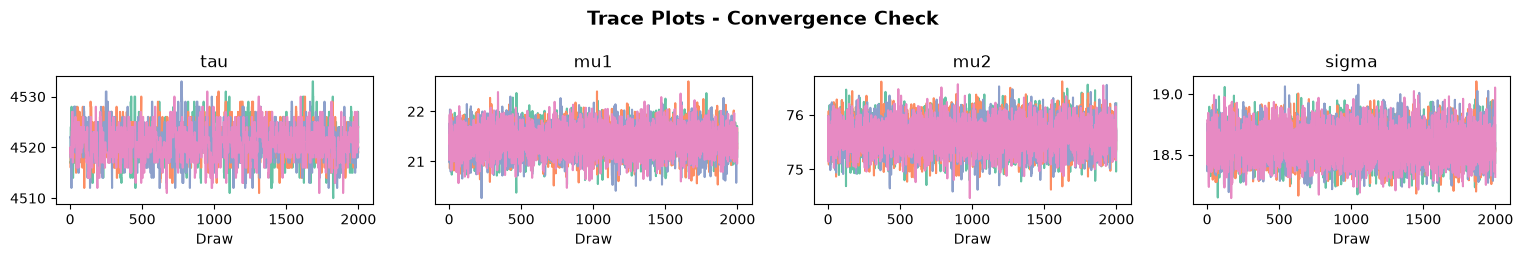

In [5]:
# ============================================================================
# 6. CHECK CONVERGENCE AND MODEL DIAGNOSTICS
# ============================================================================
# r_hat values close to 1.0 indicate good convergence
# Values > 1.05 indicate problems

print("="*60)
print("MODEL DIAGNOSTICS")
print("="*60)

# Summary of the posterior distributions
summary = az.summary(trace)
print("\nPosterior Summary:")
print(summary)

# Check r_hat values
print("\nConvergence check (r_hat should be close to 1.0):")
print(summary['r_hat'])

# Visualize trace plots
az.plot_trace(trace, var_names=['tau', 'mu1', 'mu2', 'sigma'])
plt.suptitle('Trace Plots - Convergence Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Most likely change point at day index: 4521
Most likely change point date: 2005-02-24


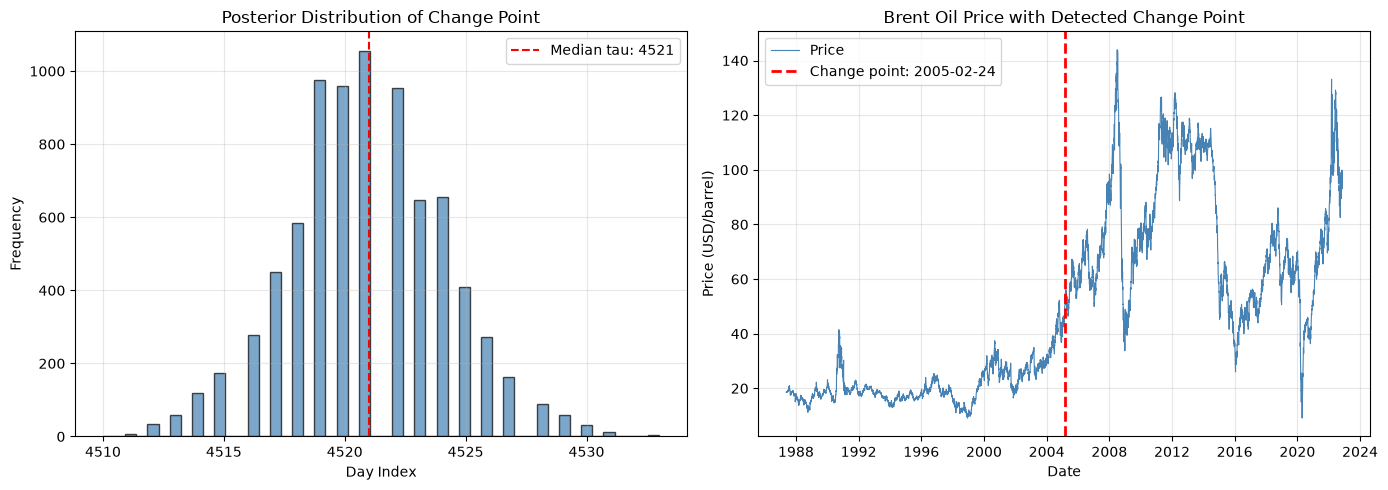


📊 Impact of the Change:
   Average price before change: $21.42
   Average price after change: $75.61
   Change: $54.19 (253.0%)


In [6]:
# ============================================================================
# 7. VISUALIZE THE CHANGE POINT POSTERIOR DISTRIBUTION
# ============================================================================
# The posterior distribution of tau shows where the change most likely occurred

# Extract the posterior samples of tau
tau_samples = trace.posterior['tau'].values.flatten()

# Plot the posterior distribution of tau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of tau
ax1.hist(tau_samples, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=np.median(tau_samples), color='red', linestyle='--', 
            label=f'Median tau: {int(np.median(tau_samples))}')
ax1.set_xlabel('Day Index')
ax1.set_ylabel('Frequency')
ax1.set_title('Posterior Distribution of Change Point')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Convert the median tau to a date
median_tau = int(np.median(tau_samples))
change_date = df.index[median_tau]
print(f"Most likely change point at day index: {median_tau}")
print(f"Most likely change point date: {change_date.strftime('%Y-%m-%d')}")

# Plot the price series with the change point marked
ax2.plot(df.index, df['Price'], color='steelblue', linewidth=0.8, label='Price')
ax2.axvline(x=change_date, color='red', linestyle='--', linewidth=2, 
            label=f'Change point: {change_date.strftime("%Y-%m-%d")}')
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (USD/barrel)')
ax2.set_title('Brent Oil Price with Detected Change Point')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the median price before and after the change
price_before = prices[:median_tau].mean()
price_after = prices[median_tau:].mean()
change_percent = ((price_after - price_before) / price_before) * 100

print(f"\n📊 Impact of the Change:")
print(f"   Average price before change: ${price_before:.2f}")
print(f"   Average price after change: ${price_after:.2f}")
print(f"   Change: ${price_after - price_before:.2f} ({change_percent:.1f}%)")

In [7]:
# ============================================================================
# 8. ASSOCIATE CHANGE POINT WITH EVENTS
# ============================================================================
# Load the events dataset and find which events align with the change point

# Load events
events_df = pd.read_csv('../data/events.csv')
events_df['Date'] = pd.to_datetime(events_df['Date'])

print("="*60)
print("CHANGE POINT ASSOCIATED EVENTS")
print("="*60)

print(f"\nDetected Change Point Date: {change_date.strftime('%Y-%m-%d')}")
print(f"Average price before: ${price_before:.2f}")
print(f"Average price after: ${price_after:.2f}")
print(f"Change: ${price_after - price_before:.2f} ({change_percent:.1f}%)")

# Find events within 30 days of the change point
window_days = 30
nearby_events = events_df[
    (events_df['Date'] >= change_date - pd.Timedelta(days=window_days)) &
    (events_df['Date'] <= change_date + pd.Timedelta(days=window_days))
]

print(f"\nEvents within ±{window_days} days of change point:")
if len(nearby_events) > 0:
    print(nearby_events[['Date', 'Event_Name', 'Category']].to_string(index=False))
else:
    print("No events found within the time window.")
    print("Try expanding the window or checking the events dataset.")

CHANGE POINT ASSOCIATED EVENTS

Detected Change Point Date: 2005-02-24
Average price before: $21.42
Average price after: $75.61
Change: $54.19 (253.0%)

Events within ±30 days of change point:
No events found within the time window.
Try expanding the window or checking the events dataset.


In [8]:
# ============================================================================
# 9. SAVE CHANGE POINT RESULTS
# ============================================================================
# Save the results to a CSV for later use

results = {
    'change_point_date': [change_date],
    'price_before': [price_before],
    'price_after': [price_after],
    'price_change': [price_after - price_before],
    'percent_change': [change_percent]
}

results_df = pd.DataFrame(results)
results_df.to_csv('../data/change_point_results.csv', index=False)

print("✅ Results saved to: ../data/change_point_results.csv")

✅ Results saved to: ../data/change_point_results.csv
